# Reservoir Computing — Prediction of Time Series

> First Meeting Emilio's notes

## 1. Introduction & Motivation

- **Not** the state of the art / most used approach
- **Advantage** → learn from the reservoir
- It mimics the brain
- **Reservoir → System** (with weighted connections)

> **Key concept:** ECHO STATE NETWORK (ESN)

**Goal:** Build an intuition


<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_39/3348995586.py:48: SyntaxWarning: invalid escape sequence '\D'
  ax.text(9.3, 2.1, 'OUTPUT\n$x(t + \Delta t)$', ha='center', va='center', fontsize=12, fontweight='bold')


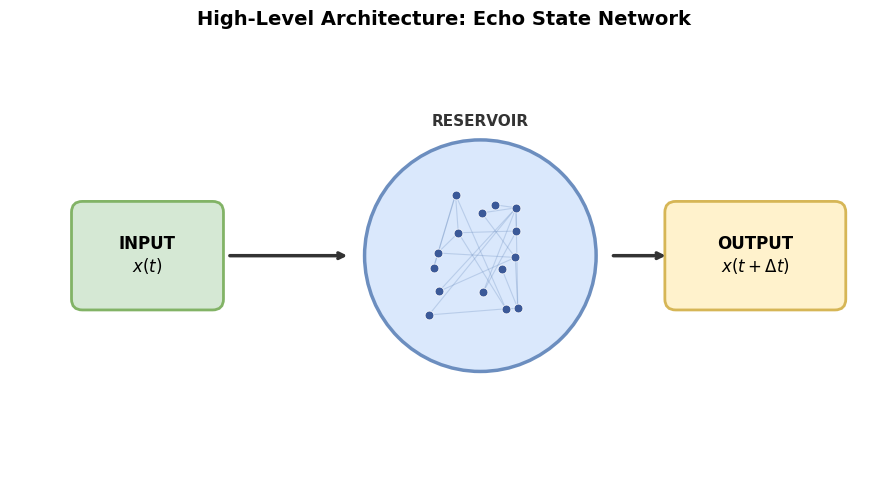

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('white')

# Input box
input_box = mpatches.FancyBboxPatch((0, 1.5), 1.8, 1.2, boxstyle="round,pad=0.15",
                                      facecolor='#D5E8D4', edgecolor='#82B366', linewidth=2)
ax.add_patch(input_box)
ax.text(0.9, 2.1, 'INPUT\n$x(t)$', ha='center', va='center', fontsize=12, fontweight='bold')

# Reservoir circle
reservoir = plt.Circle((5.5, 2.1), 1.6, facecolor='#DAE8FC', edgecolor='#6C8EBF', linewidth=2.5)
ax.add_patch(reservoir)
ax.text(5.5, 3.95, 'RESERVOIR', ha='center', va='center', fontsize=11, fontweight='bold', color='#333')

# Random nodes inside the reservoir
np.random.seed(42)
n_nodes = 15
angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False) + np.random.uniform(-0.2, 0.2, n_nodes)
radii = np.random.uniform(0.3, 1.3, n_nodes)
node_x = 5.5 + radii * np.cos(angles)
node_y = 2.1 + radii * np.sin(angles)

# Random edges (messy connections)
np.random.seed(7)
for i in range(n_nodes):
    n_connections = np.random.randint(1, 4)
    targets = np.random.choice(n_nodes, n_connections, replace=False)
    for t in targets:
        if t != i:
            ax.plot([node_x[i], node_x[t]], [node_y[i], node_y[t]],
                    color='#6C8EBF', alpha=0.3, linewidth=0.8)

ax.scatter(node_x, node_y, s=40, c='#3B5998', zorder=5, edgecolors='white', linewidth=0.5)

# Output box
output_box = mpatches.FancyBboxPatch((8.2, 1.5), 2.2, 1.2, boxstyle="round,pad=0.15",
                                       facecolor='#FFF2CC', edgecolor='#D6B656', linewidth=2)
ax.add_patch(output_box)
ax.text(9.3, 2.1, 'OUTPUT\n$x(t + \Delta t)$', ha='center', va='center', fontsize=12, fontweight='bold')

# Arrows
ax.annotate('', xy=(3.7, 2.1), xytext=(2.0, 2.1),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))
ax.annotate('', xy=(8.1, 2.1), xytext=(7.3, 2.1),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))

ax.set_title('High-Level Architecture: Echo State Network', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 2. The Lake Analogy (Building Intuition)

> **LAKE → RAIN → Not the drop will tell, by looking at the surface**

- We observe the surface of a lake (the reservoir's state), and from that we can infer properties of the input (the rain), even though we can't see the rain drops individually.
- We can use the **output** to **predict the next step**.
- **"We're good for fixed time series"**
- **"Not a reservoir yet"** — we don't know what's inside the reservoir
- Advantage → **depending on what you put in the reservoir, it works better or worse**
  - Example application: **STOCK** prediction


## 3. Assumptions

- **Input is NOT completely random** (chaotic input is acceptable, but not pure noise)
- For explanatory/introductory purposes, this simplification is good


## 4. Reservoir Dynamics — Mathematical Formulation

### State Variable

$r_i(t)$ = rate → number of states/second (firing rate of neuron $i$)

### Derivative (Continuous)

$$\frac{dr_i(t)}{dt} = \frac{r_i(t + \Delta t) - r_i(t)}{\Delta t}$$

> "We simulate on the computer"

### Full Reservoir Dynamics Equation

$$\frac{dr_i}{dt} = -r_i(t) + S\!\left(\sum_{j=1}^{N} W_{ij}\, r_j(t) + W^{\text{in}}\, x_i(t)\right)$$

Where:
- $S(\cdot)$ = nonlinear activation function (e.g., sigmoid $\sigma$ or **tanh**)
- $W$ = internal reservoir weight matrix
- $W^{\text{in}}$ = input weight matrix
- $x(t)$ = input signal
- $N$ = number of neurons in the reservoir


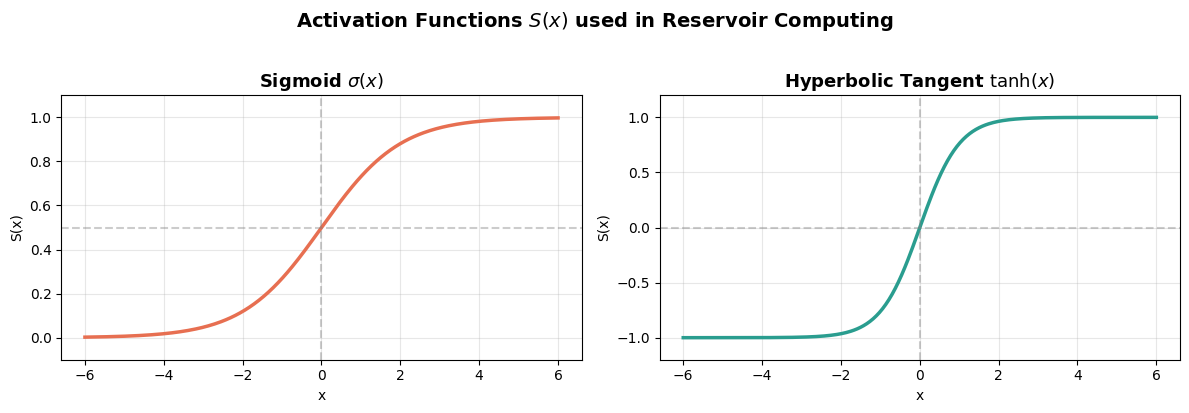

In [2]:
# Activation Function S(x): sigmoid and tanh
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(-6, 6, 300)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-x))
axes[0].plot(x, sigmoid, color='#E76F51', linewidth=2.5)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.4)
axes[0].set_title('Sigmoid $\\sigma(x)$', fontsize=13, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('S(x)')
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True, alpha=0.3)

# Tanh
tanh = np.tanh(x)
axes[1].plot(x, tanh, color='#2A9D8F', linewidth=2.5)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.4)
axes[1].set_title('Hyperbolic Tangent $\\tanh(x)$', fontsize=13, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('S(x)')
axes[1].set_ylim(-1.2, 1.2)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Activation Functions $S(x)$ used in Reservoir Computing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Euler Method (Numerical Integration)

### Discretization

$$r_i(t + \Delta t) = r_i(t) + \Delta t \left[-r_i(t) + S\!\left(\sum_j W_{ij}\, r_j(t) + W^{\text{in}}\, x_i(t)\right)\right]$$

- **EULER Method** = approximate method
- $\Delta t \downarrow$ → more exact approximation
- $\Delta t = 0.01$ → safe choice

### Output / Readout

$$y = W^{\text{out}}\, r$$

$$\hat{y}(t) = X(t + \Delta t)$$

> Target: predict the next time step of the input


## 6. Recurrent Networks vs. Reservoir

- **Recurrent Network → more difficult** than other approaches (training-wise)
- Reservoir computing simplifies this by **only training the readout** $W^{\text{out}}$


## 7. Constructing the Reservoir (Step-by-Step Plan)

1. **Start constructing Reservoir without input** → make sure it works
2. **Simulate diff eq without input**
3. Can be done:
   - **By hand** (Euler method) → more interesting / instructive
   - Using a **package**


<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_39/3802277715.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(t[split-1:], signal[split-1:], color='#E76F51', linewidth=2, linestyle='--', label='Predicted $\hat{x}(t+\Delta t)$')


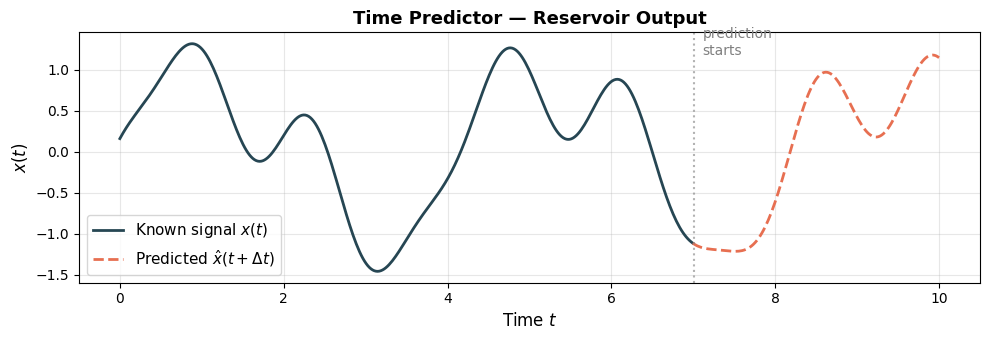

In [3]:
# Time Predictor illustration
fig, ax = plt.subplots(figsize=(10, 3.5))

t = np.linspace(0, 10, 500)
signal = np.sin(1.5*t) + 0.5*np.sin(3.2*t) + 0.3*np.cos(5*t + 1)

split = 350
ax.plot(t[:split], signal[:split], color='#264653', linewidth=2, label='Known signal $x(t)$')
ax.plot(t[split-1:], signal[split-1:], color='#E76F51', linewidth=2, linestyle='--', label='Predicted $\hat{x}(t+\Delta t)$')
ax.axvline(x=t[split], color='gray', linestyle=':', alpha=0.6)
ax.text(t[split]+0.1, max(signal)*0.9, 'prediction\nstarts', fontsize=10, color='gray')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$x(t)$', fontsize=12)
ax.set_title('Time Predictor — Reservoir Output', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

# Page 2 — Building the Reservoir System

---

## 8. Which Features of the Reservoir Matter?

- **Reservoir → we start with synthetic nets → and we check if they work**

### General Dynamical System

$$\frac{dr}{dt} = g(r, t)$$

This **alters the computational capability** of the reservoir.

### Euler Discretization (General)

$$\frac{V(t + \Delta t) - V(t)}{\Delta t} = g(V, t)$$

$$V(t + \Delta t) = x(t) + \Delta t \cdot g(r, t) \quad \text{(Normal Euler form)}$$


## 9. Input Requirements

- **INPUT → must be complicated to predict**
- Example: $x(t)$ = **Lorenz system**
- **ANY small number** (perturbation) → **Lyapunov** exponent → **huge divergence**


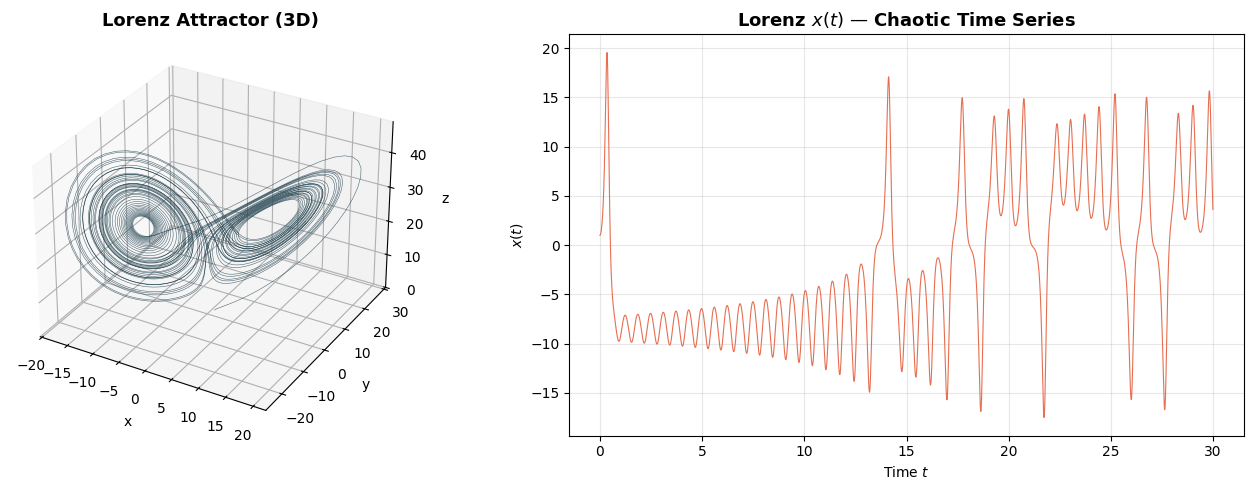

In [4]:
from scipy.integrate import solve_ivp

# Lorenz system as example of chaotic input
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

sol = solve_ivp(lorenz, [0, 50], [1.0, 1.0, 1.0], max_step=0.01, dense_output=True)

fig = plt.figure(figsize=(14, 5))

# 3D attractor
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(sol.y[0], sol.y[1], sol.y[2], linewidth=0.4, color='#264653', alpha=0.8)
ax1.set_title('Lorenz Attractor (3D)', fontsize=13, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# Time series of x(t)
ax2 = fig.add_subplot(122)
ax2.plot(sol.t[:3000], sol.y[0][:3000], linewidth=0.8, color='#E76F51')
ax2.set_title('Lorenz $x(t)$ — Chaotic Time Series', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel('$x(t)$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Loss Function

$$\text{Loss} = \text{MSE} \quad (\text{Mean Squared Error})$$


## 11. Two Ways to Evaluate the Reservoir

1. **Time series of reservoir states** $x(t)$
2. **Phase space** — last $k$ steps


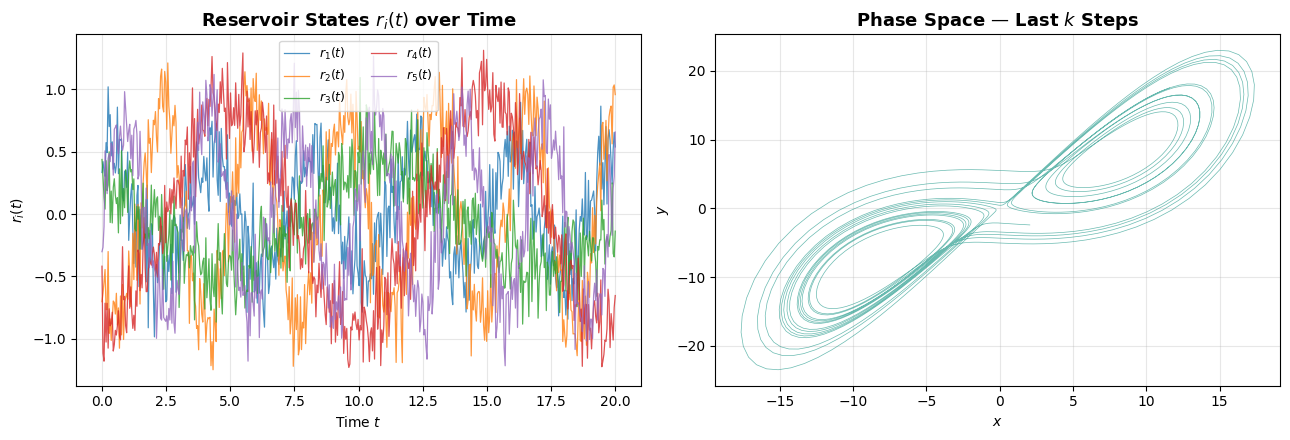

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Visualization 1: time series of multiple reservoir neurons
np.random.seed(12)
t = np.linspace(0, 20, 500)
for i in range(5):
    phase = np.random.uniform(0, 2*np.pi)
    freq = np.random.uniform(0.5, 2.0)
    amp = np.random.uniform(0.3, 1.0)
    signal = amp * np.sin(freq*t + phase) + 0.2*np.random.randn(len(t))
    axes[0].plot(t, signal, linewidth=0.9, alpha=0.8, label=f'$r_{i+1}(t)$')
axes[0].set_title('Reservoir States $r_i(t)$ over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('$r_i(t)$')
axes[0].legend(fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# Visualization 2: phase space (last k steps)
sol_lorenz = solve_ivp(lorenz, [0, 50], [1.0, 1.0, 1.0], max_step=0.01, dense_output=True)
k = 2000
axes[1].plot(sol_lorenz.y[0][-k:], sol_lorenz.y[1][-k:], linewidth=0.5, color='#2A9D8F', alpha=0.7)
axes[1].set_title('Phase Space — Last $k$ Steps', fontsize=13, fontweight='bold')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Step ①: Build the Dynamical System

> "Now we have a system for which **we know what will happen**"

### Reservoir Update Equation (without input, for testing)

$$r_i(t + \Delta t) = r_i(t) + \Delta t \left[-r_i(t) + S\!\left(\sum_{j} W_{ij}\, r_j(t)\right)\right]$$

- Vectors → done with **NumPy**
- $N$ = number of neurons

### Weight Matrix

$$W_{ij} \sim \mathcal{N}\!\left(0,\; \frac{\sigma^2}{N}\right)$$

- **Random matrix**, scaled by $1/N$ (number of nodes) for proper normalization


## 13. Coupling Strength $J$ — Edge of Chaos

The reservoir works best at the **boundary** ($J \approx 1$), balancing stability and complexity.

- For $J < 1$: reservoir states **decay and stabilize** → the system reaches a rest/fixed point
- For $J > 1$: reservoir activity becomes **chaotic** → trajectories diverge


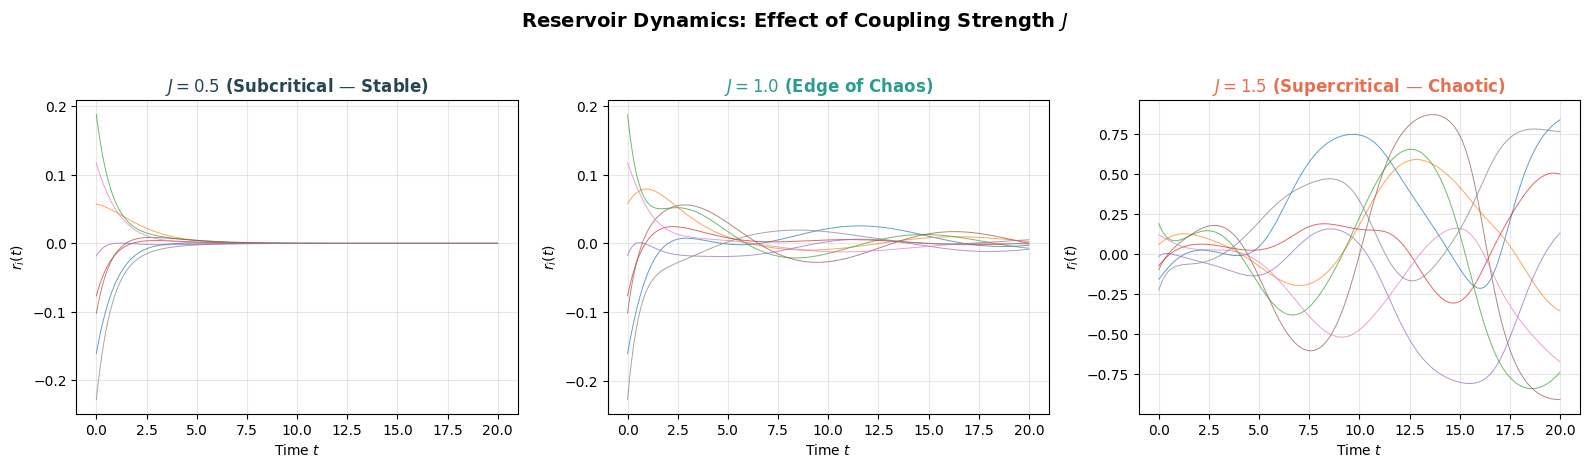

In [6]:
# Simulating reservoir dynamics for J < 1, J ≈ 1, and J > 1
N = 50       # number of neurons
dt = 0.01
T = 20
steps = int(T / dt)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
J_values = [0.5, 1.0, 1.5]
titles = ['$J = 0.5$ (Subcritical — Stable)', '$J = 1.0$ (Edge of Chaos)', '$J = 1.5$ (Supercritical — Chaotic)']
colors = ['#264653', '#2A9D8F', '#E76F51']

for idx, (J, title, color) in enumerate(zip(J_values, titles, colors)):
    np.random.seed(0)
    W = np.random.randn(N, N) * J / np.sqrt(N)
    r = np.random.randn(N) * 0.1  # small initial state
    
    r_history = np.zeros((steps, N))
    for step in range(steps):
        dr = -r + np.tanh(W @ r)
        r = r + dt * dr
        r_history[step] = r
    
    t_axis = np.arange(steps) * dt
    for i in range(min(8, N)):
        axes[idx].plot(t_axis, r_history[:, i], linewidth=0.7, alpha=0.7)
    
    axes[idx].set_title(title, fontsize=12, fontweight='bold', color=color)
    axes[idx].set_xlabel('Time $t$')
    axes[idx].set_ylabel('$r_i(t)$')
    axes[idx].grid(True, alpha=0.3)

fig.suptitle('Reservoir Dynamics: Effect of Coupling Strength $J$', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 14. Evaluating Variability

- **Looking at different areas** (of parameter space)
- **Looking at variability between individuals** → interesting

### Metric

$$E\!\left[\text{Var}(r_i,\, c_k)\right] \quad \text{over realizations of } r, W$$

Expectation of the variance of neuron activities across different **realizations** of the reservoir (different random weight matrices $W$).


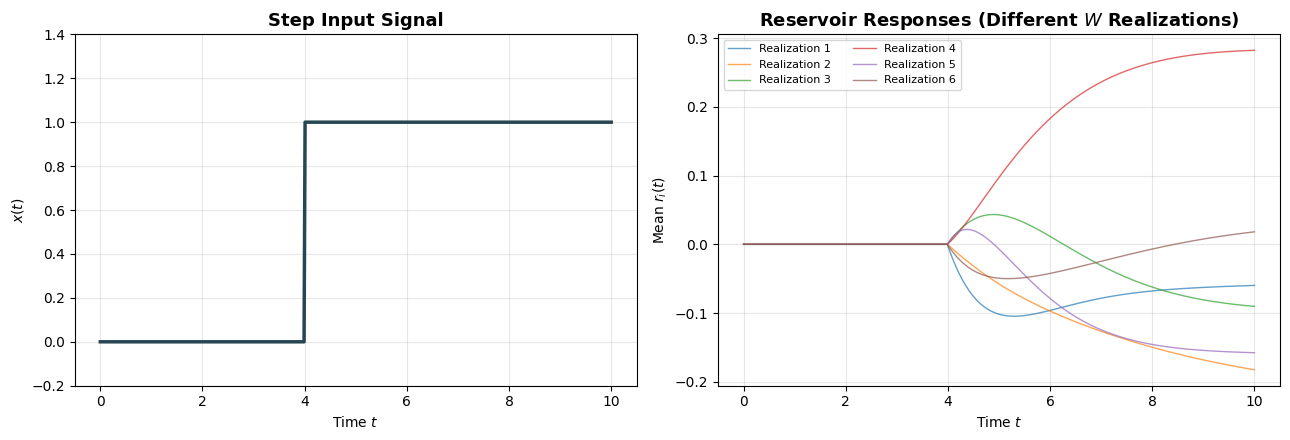

In [7]:
# Step function input and reservoir response across realizations
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Step input
t_step = np.linspace(0, 10, 500)
step_input = np.where(t_step >= 4, 1.0, 0.0)
axes[0].plot(t_step, step_input, color='#264653', linewidth=2.5)
axes[0].set_title('Step Input Signal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('$x(t)$')
axes[0].set_ylim(-0.2, 1.4)
axes[0].grid(True, alpha=0.3)

# Multiple reservoir responses to step input (different W realizations)
N = 30
dt = 0.02
steps = len(t_step)
J = 0.9

for trial in range(6):
    np.random.seed(trial * 10)
    W = np.random.randn(N, N) * J / np.sqrt(N)
    W_in = np.random.randn(N) * 0.5
    r = np.zeros(N)
    r_mean_history = []
    
    for step in range(steps):
        x_t = step_input[step]
        dr = -r + np.tanh(W @ r + W_in * x_t)
        r = r + dt * dr
        r_mean_history.append(np.mean(r[:5]))
    
    axes[1].plot(t_step, r_mean_history, linewidth=1.0, alpha=0.7, label=f'Realization {trial+1}')

axes[1].set_title('Reservoir Responses (Different $W$ Realizations)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('Mean $r_i(t)$')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## Summary of Key Concepts

| Concept | Description |
|---|---|
| **Reservoir** | Random recurrent network (fixed weights) |
| **Echo State Network** | Main framework for reservoir computing |
| **Euler Method** | Numerical integration ($\Delta t = 0.01$ safe) |
| **Activation $S(\cdot)$** | Nonlinear function, typically tanh |
| **Readout** | $y = W^{\text{out}} \cdot r$ (only trained part) |
| **Loss** | MSE |
| **Coupling $J$** | $J < 1$ → stable; $J > 1$ → chaotic; $J \approx 1$ → optimal |
| **Weight scaling** | $W_{ij} \sim \mathcal{N}(0, \sigma^2/N)$ |
| **Input requirement** | Must be complex/chaotic (e.g., Lorenz system) |
| **Evaluation** | $E[\text{Var}(r_i, c_k)]$ across realizations of $r$, $W$ |
